
*  DSC 530
*  Week 9 & 10 Assignment
*  Saebastion Cole

# Hands-on data analysis with Pandas

In [18]:
# Before I do anything I am starting with the imports.
# I am opting to stick with pandas and sklearn as these are what was used in the book.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
# Import the modeling libraries
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import fowlkes_mallows_score

# I will also load the data from the csv here.
red_wine = pd.read_csv("data/winequality-red.csv")

# This file from github for some reason wasn't actually in csv format. it was seperated by semicolons. I will use the sep argument to fix this.
white_wine = pd.read_csv("data/winequality-white.csv", sep=";")

stars = pd.read_csv("data/stars.csv")
planets = pd.read_csv("data/planets.csv")

# Chapter 9 Exercises

## Exercise 1: Clustering Model

1. Combine the red and white wine datasets (data/winequality-red.csv and data/winequality-white.csv, respectively) and add a column for the kind of wine (red or white).

In [19]:
# Actually doing this backwards to how it was asked because we lose what the source was once we combine them.


# Add the new column with the type.
red_wine["kind_of_wine"] = "red"
white_wine["kind_of_wine"] = "white"

# Concat both of the dataframes into the one.
wine = pd.concat([red_wine, white_wine], ignore_index=True)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,kind_of_wine
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


2. Build and fit a pipeline that scales the data and then uses k-means clustering to make two clusters. Be sure not to use the quality column.

In [20]:
# Combine the two dataframes again

wine = pd.concat([red_wine, white_wine], ignore_index=True)

kmeans_wine_data = wine.copy()

kmeans_wine_data.drop(columns=["kind_of_wine"], inplace=True)
kmeans_wine_data.drop(columns=["quality"], inplace=True)

kmeans_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=2, random_state=42))])

kmeans_pipeline.fit(kmeans_wine_data)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [21]:
kmeans_wine_data["cluster"] = kmeans_pipeline.predict(kmeans_wine_data)
kmeans_wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


3. Use the Fowlkes-Mallows Index (the fowlkes_mallows_score() function is in sklearn.metrics) to evaluate how well k-means is able to make the distinction between red and white wine.

In [22]:
fowlkes_mallows_score(wine["kind_of_wine"], kmeans_wine_data["cluster"])

0.9776918113120894

4. Find the center of each cluster.

In [23]:
kmeans = kmeans_pipeline.named_steps["kmeans"]
kmeans.cluster_centers_

# We need to get the columns from the original data to see where the center exists.
feature_columns = kmeans_wine_data.columns.drop("cluster")

scaler = kmeans_pipeline.named_steps["scaler"]

# Take the centers of each column for each cluster and put it into a data frame
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_columns
)
centers


# Add column name for the colors of wine we are using for the clusters
centers.index = ["red", "white"]

# Show the data
centers.T

,red,white
fixed acidity,8.288200,6.851855
volatile acidity,0.531819,0.274572
citric acid,0.269544,0.335263
residual sugar,2.633151,6.395178
chlorides,0.088383,0.045075
free sulfur dioxide,15.762470,35.526375
total sulfur dioxide,48.724453,138.448279
density,0.996738,0.994005
pH,3.309605,3.187639
sulphates,0.656697,0.488778


## Exercise 2: Predict star temperature

Using the data/stars.csv file, perform some initial EDA and then build a linear regression model of all the numeric columns to predict the temperature of the star.
Train the model on 75% of the initial data.
Calculate the R2 and RMSE of the model.
Find the coefficients for each regressor and the intercept of the linear regression equation.
Visualize the residuals using the plot_residuals() function from the ml_utils.regression module.

In [24]:
# Starting with some EDA on the stars data to see what I am working with.



print("Shape:", stars.shape)
print()
print("Null counts:")
print(stars.isna().sum())

stars.describe().T

Shape: (3183, 12)

Null counts:
temperature      390
magV            1909
mass              93
spectraltype    1977
magJ            1620
radius           462
magB            2180
magH            1627
magK            1598
metallicity      772
name               0
planets            0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
temperature,2793.0,5532.146084,1715.076581,485.000000,5078.00000,5627.0000,5949.00000,57000.00
magV,1274.0,10.304334,3.148937,0.010000,7.95000,10.4715,12.54350,24.30
mass,3090.0,0.960175,0.362107,0.010000,0.80725,0.9640,1.11000,4.50
magJ,1563.0,9.899493,3.226399,-1.150000,7.01350,10.6000,12.60750,21.60
radius,2721.0,1.605091,3.689890,0.000014,0.81200,0.9990,1.27000,83.80
magB,1003.0,10.730635,3.032962,0.720000,8.51250,10.8100,13.01000,19.86
magH,1556.0,9.525366,3.253978,-1.380000,6.66475,10.2485,12.23025,20.80
magK,1585.0,9.408291,3.214560,-1.490000,6.58900,10.1610,12.11900,19.16
metallicity,2411.0,0.017893,0.183447,-2.090000,-0.06000,0.0200,0.11000,0.56
planets,3183.0,1.273327,0.853176,0.000000,1.00000,1.0000,1.00000,9.00


In [25]:
# A linear regression can't take nulls so I keep only the numeric columns and drop the incomplete rows.

star_data = stars.select_dtypes(include="number").dropna()

print("Rows left after dropping nulls:", star_data.shape[0])

# Check how each numeric column relates to temperature before modeling.
star_data.corr()["temperature"].sort_values()

Rows left after dropping nulls: 596


radius        -0.303827
planets       -0.076696
magB          -0.048724
magV           0.037660
metallicity    0.082751
magJ           0.243704
magH           0.275694
magK           0.293105
mass           0.340194
temperature    1.000000
Name: temperature, dtype: float64

In [26]:
# Now I can build the model. Temperature is what I am predicting so everything else numeric is a regressor.

star_X = star_data.drop(columns=["temperature"])
star_y = star_data["temperature"]

# Train on 75% of the data like the exercise asks for.
X_train, X_test, y_train, y_test = train_test_split(
    star_X, star_y, train_size=0.75, random_state=42
)

star_model = LinearRegression().fit(X_train, y_train)

# Predict on the test set so I can score the model on data it hasn't seen.
star_preds = star_model.predict(X_test)

print("R2:", r2_score(y_test, star_preds))

# mean_squared_error no longer takes the squared argument in this version of sklearn so I take the root myself.
print("RMSE:", np.sqrt(mean_squared_error(y_test, star_preds)))

R2: 0.8022345289681736
RMSE: 417.1937340677064


In [27]:
# Now the coefficients for each regressor and the intercept of the equation.

star_coefficients = pd.Series(star_model.coef_, index=star_X.columns)

print("Intercept:", star_model.intercept_)
star_coefficients

Intercept: 6627.053939719715


magV           -187.327205
mass            176.154868
magJ           -962.345485
radius            7.773255
magB           -301.036061
magH            -11.135923
magK           1504.503385
metallicity      22.263296
planets         -27.931391
dtype: float64

Text(0.5, 0.98, 'Residuals')

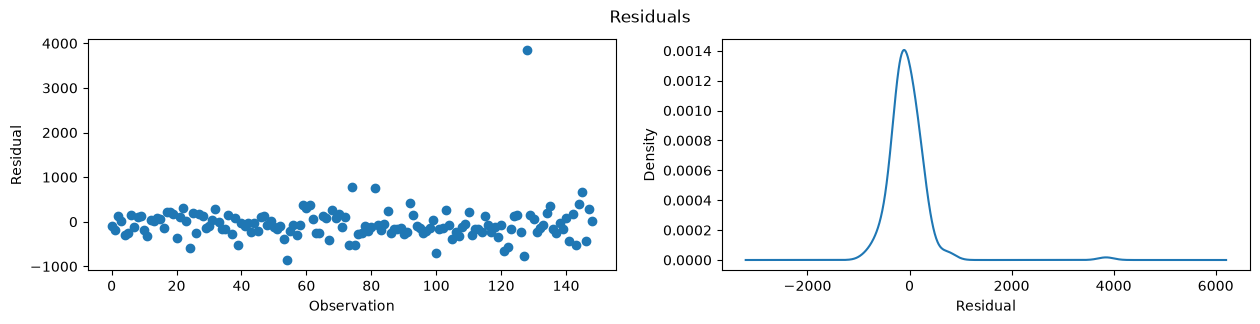

In [28]:
# Last is visualizing the residuals.
# The ml_utils module from the book isn't installed here so I am drawing the same two plots directly.
# The left plot is the residual for each observation and the right one is the KDE of the residuals.

residuals = y_test - star_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 3))

axes[0].scatter(np.arange(residuals.shape[0]), residuals)
axes[0].set_xlabel("Observation")
axes[0].set_ylabel("Residual")

residuals.plot(kind="kde", ax=axes[1])
axes[1].set_xlabel("Residual")

plt.suptitle("Residuals")

## Exercise 3: Classify planets that have shorter years than Earth

Using the data/planets.csv file, build a logistic regression model with the eccentricity, semimajoraxis, and mass columns as regressors. You will need to make a new column to use for the y (year shorter than Earth).
Find the accuracy score.
Use the classification_report() function from scikit-learn to see the precision, recall, and F1 score for each class.
With the plot_roc() function from the ml_utils.classification module, plot the ROC curve.
Create a confusion matrix using the confusion_matrix_visual() function from the ml_utils.classification module.

In [29]:
# Load the planets data and keep only the columns I need for this model plus period to build the target.



planet_data = planets[["eccentricity", "semimajoraxis", "mass", "period"]].dropna()

# The target column. An Earth year is 365.26 days so anything under that is a shorter year.
planet_data["shorter_than_earth"] = (planet_data["period"] < 365.26).astype(int)

print("Rows left after dropping nulls:", planet_data.shape[0])
print()
print(planet_data["shorter_than_earth"].value_counts())

planet_data.head()

Rows left after dropping nulls: 1222

shorter_than_earth
1    822
0    400
Name: count, dtype: int64


,eccentricity,semimajoraxis,mass,period,shorter_than_earth
0,0.231,1.290,19.400,326.03,1
1,0.080,1.540,11.200,516.22,0
2,0.000,0.830,4.800,185.84,1
3,0.359,2.864,4.975,1766.00,0
4,0.184,9.037,7.679,9886.00,0


In [30]:
# Now fit the logistic regression on 75% of the data.

planet_X = planet_data[["eccentricity", "semimajoraxis", "mass"]]
planet_y = planet_data["shorter_than_earth"]

planet_X_train, planet_X_test, planet_y_train, planet_y_test = train_test_split(
    planet_X, planet_y, test_size=0.25, random_state=42, stratify=planet_y
)

planet_model = LogisticRegression(random_state=42).fit(planet_X_train, planet_y_train)

planet_preds = planet_model.predict(planet_X_test)

print("Accuracy:", accuracy_score(planet_y_test, planet_preds))

Accuracy: 0.9803921568627451


In [31]:
# The classification report gives the precision, recall and F1 score for each class.

print(classification_report(planet_y_test, planet_preds, target_names=["longer year", "shorter year"]))

              precision    recall  f1-score   support

 longer year       0.97      0.97      0.97       100
shorter year       0.99      0.99      0.99       206

    accuracy                           0.98       306
   macro avg       0.98      0.98      0.98       306
weighted avg       0.98      0.98      0.98       306



Text(0.5, 0, 'AUC: 1.0')

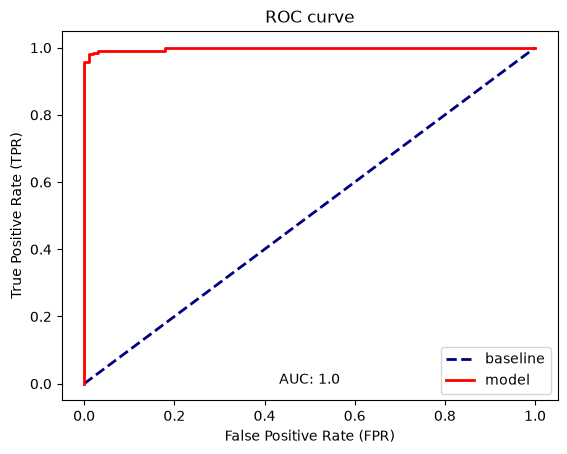

In [32]:


planet_probs = planet_model.predict_proba(planet_X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(planet_y_test, planet_probs)

fig, ax = plt.subplots(1, 1)

# The diagonal is what random guessing would look like.
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="baseline")
ax.plot(fpr, tpr, color="red", lw=2, label="model")

ax.legend(loc="lower right")
ax.set_title("ROC curve")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (TPR)")

# The area under the curve tells me how much better than the baseline the model is.
ax.annotate(f"AUC: {auc(fpr, tpr):.2}", xy=(0.5, 0), horizontalalignment="center")

Text(0.5, 1.0, 'Confusion Matrix')

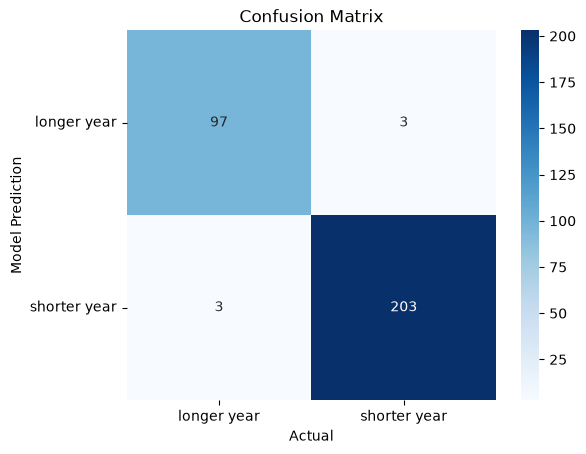

In [33]:
# Last is the confusion matrix. Same idea as the confusion_matrix_visual() helper, drawn with seaborn.

matrix = confusion_matrix(planet_y_test, planet_preds)

# Transposing puts the predictions on the y axis and the actual values on the x axis like the book does.
ax = sns.heatmap(matrix.T, square=True, annot=True, fmt="d", cmap="Blues")

ax.set_xlabel("Actual")
ax.set_ylabel("Model Prediction")

class_labels = ["longer year", "shorter year"]
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels, rotation=0)

ax.set_title("Confusion Matrix")